# Synthetic Dataset for Lasso (1000+ rows)
This will generate:
- 1200 rows
- 20 features
- Only 5 important features
- Rest are noise features
- Perfect for demonstrating Lasso feature elimination.

#### What is Lasso Regression?
- Lasso Regression is a type of Linear Regression with Regularization.
- It adds a penalty to the model coefficients to prevent overfitting.

**Lasso stands for:**
- Least Absolute Shrinkage and Selection Operator

**Main purpose:**
- Reduce overfitting
- Perform automatic feature selection
- Make the model simpler

**When to Use Lasso**
##### Use Lasso when:
- Dataset has many features
- Some features are irrelevant
- You want automatic feature selection

**Common examples:**
- Marketing data
- Genomics data
- Text features

In [1]:
import pandas as pd 
from sklearn.datasets import make_regression

In [2]:
# create synthetic dataset 
X, y, coef = make_regression(
    n_samples= 1200, # for rows 
    n_features= 20, # total features or cols 
    n_informative= 5, # important features 
    noise = 10, 
    coef= True, 
    random_state= 42
)

In [3]:
# Converting to dataframe 
columns = [f'feature_{i}' for i in range(20)]
df = pd.DataFrame(X, columns= columns)

In [5]:
# Add the target column 
df['target'] = y

In [6]:
df.head() 

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,-0.169852,-0.183301,-0.036590,-0.500198,1.090183,-0.373368,0.381734,-0.019794,-0.482314,-0.748096,-1.967325,1.515445,1.098983,-0.326673,0.124752,0.293538,0.659650,-0.021245,0.249418,1.636740,55.586270
1,-0.765135,1.191720,-0.765653,0.466147,-1.856432,0.343049,-0.427111,0.705894,0.932375,0.403888,-1.273161,0.037014,0.171921,0.003774,0.244241,-0.621766,-0.282160,1.132406,-0.095613,0.426368,-190.218275
2,0.018999,0.618407,1.174814,0.846771,-0.327795,-0.646528,0.787543,-0.727454,0.638184,-0.041660,0.015909,-0.611516,0.212726,-0.368058,-0.407589,0.610440,-1.878981,0.180496,-0.035407,-0.521255,-43.262429
3,0.430143,0.422629,-0.641416,1.134769,0.275396,1.176011,-0.090243,-2.013825,0.118330,0.913712,0.186093,1.253058,-1.116064,1.451927,-0.947531,0.223524,1.110678,1.296257,-1.483979,0.508535,43.971445
4,-1.941568,0.346117,-1.710603,0.365760,-1.567988,-0.264546,-0.766323,0.492014,2.064220,-1.492462,-1.001315,0.894233,0.158095,-0.506189,-0.179515,-0.954618,-0.393090,-0.922189,0.518219,-2.384906,-186.927384


In [7]:
df.shape

(1200, 21)

# Train Lasso On This Dataset 

In [8]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import Lasso 

In [9]:
X = df.drop('target', axis= 1) 
y = df['target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [11]:
lasso = Lasso(alpha= 0.1)

In [12]:
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [13]:
print("Coefficients:")
print(lasso.coef_)

Coefficients:
[ 3.87395551e-01  8.38098282e-02  4.29948575e-01 -1.97856093e-01
  8.54613415e+01 -2.27389514e-02  3.03357408e-01 -1.05118694e-01
 -3.11526585e-01  8.76244058e+00  2.12789455e+01  2.57510473e-01
 -4.30937257e-02 -2.69957606e-01  0.00000000e+00  4.48383990e-01
  1.02896436e+01  3.43895443e-01 -2.14558373e-01  0.00000000e+00]


# Showing Important Features 

In [14]:
selected_features = X.columns[lasso.coef_ != 0]

print('selected features : ')
print(selected_features)

selected features : 
Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_15',
       'feature_16', 'feature_17', 'feature_18'],
      dtype='object')


In [15]:
df.to_csv('lasso_synthetic_dataset.csv', index = False)

# Lasso Path

#### The Lasso Path graph shows how feature coefficients change when the regularization strength (alpha / λ) increases.

**In the graph:**
- X-axis → Regularization strength (alpha / λ)
- Y-axis → Coefficient values
- Each line → One feature

#### What Happens in the Graph
**Left side (small λ)** 
- Model behaves like Linear Regression
- All features have non-zero coefficients

**Middle (λ increasing)**
- Lasso starts shrinking coefficients

**Right side (large λ)**
- Some coefficients become exactly 0
- Those features are removed from the model

In [18]:
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt 
import seaborn as sns 

(np.float64(0.06304544650811764),
 np.float64(125.7922035480334),
 np.float64(-4.725101582843546),
 np.float64(89.58955088884238))

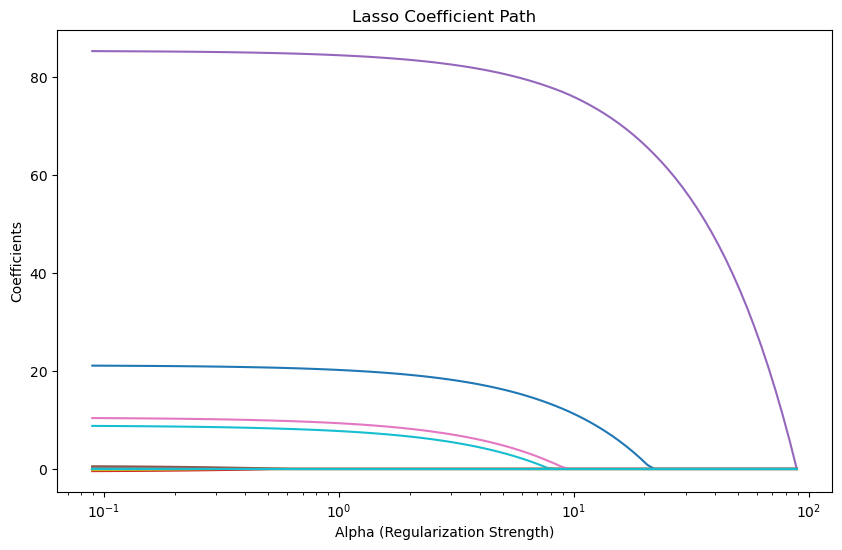

In [19]:
# Compute Lasso path
alphas, coefs, _ = lasso_path(X, y)

# Plot coefficient paths
plt.figure(figsize=(10,6))

for coef in coefs:
    plt.plot(alphas, coef)

plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Coefficients")
plt.title("Lasso Coefficient Path")
plt.axis("tight")


### Lasso Regression is a linear regression technique that uses L1 regularization to shrink coefficients and automatically set some of them to zero, helping prevent overfitting and select important features.